Step-1:
Data Loading Or Data Ingestion
Imported pandas, matplotlib, and seaborn for data analysis and visualization. Loaded multiple CSV datasets using read_csv() into DataFrames for further processing.
This step is called data loading, which prepares data for cleaning, analysis, and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")

Step-2:
Used .shape, .head(), .info(), and .isnull().sum() in pandas to explore dataset size, structure, data types, and missing values.
This step is called EDA (Exploratory Data Analysis) and helps identify issues before data cleaning and analysis.

In [2]:
# Run these for each dataframe
orders.shape
orders.head()
orders.info()
orders.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Cleaned data by removing missing delivery records and filtering only delivered orders. Converted date columns to datetime and created new features like delivery delay and order month for analysis.
This step is called data cleaning + feature engineering and prepares data for insights.

In [3]:
# Drop rows where delivery date is missing
orders.dropna(subset=["order_delivered_customer_date"], inplace=True)

# Convert date columns to datetime
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Keep only delivered orders
orders = orders[orders["order_status"] == "delivered"]

# Create delivery delay column (in days)
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"] - 
    orders["order_estimated_delivery_date"]
).dt.days

# Extract month-year for trend analysis
orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M")

Removed duplicate rows using .drop_duplicates() to ensure accurate analysis and avoid double counting.
Checked missing values using .isnull().sum() to confirm data quality.

In [3]:
items.drop_duplicates(inplace=True)
items.isnull().sum()  # check — usually clean

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Removed rows with missing product categories, renamed column for clarity, and kept only relevant columns (product_id, category).
This step simplifies and prepares the dataset for efficient analysis and merging.

In [4]:
# Drop rows with missing category
products.dropna(subset=["product_category_name"], inplace=True)

# Rename long category column
products.rename(columns={
    "product_category_name": "category"
}, inplace=True)

# Keep only useful columns
products = products[["product_id", "category"]]

Selected only order_id and review_score to simplify the dataset and removed duplicate reviews to keep one review per order.
This ensures clean and accurate data for analysis and merging.

In [5]:
# Keep only needed columns
reviews = reviews[["order_id", "review_score"]]

# Drop duplicates — keep first review per order
reviews.drop_duplicates(subset="order_id", keep="first", inplace=True)

In [6]:
# Merge orders + items
df = pd.merge(orders, items, on="order_id", how="inner")

# Merge with products
df = pd.merge(df, products, on="product_id", how="left")

# Merge with reviews
df = pd.merge(df, reviews, on="order_id", how="left")

# Check final shape
print(df.shape)
print(df.isnull().sum())

(110189, 18)
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date        1
order_delivered_customer_date       0
order_estimated_delivery_date       0
delivery_delay_days                 0
order_month                         0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
category                         1537
review_score                      827
dtype: int64


In [7]:
df.to_csv("olist_cleaned.csv", index=False)
print("Saved successfully!")

Saved successfully!


Create a new file olist_eda.ipynb

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("olist_cleaned.csv")
sns.set_style("whitegrid")

Question 1 — Which categories generate the most revenue?

C:\Users\yadua\AppData\Local\Temp\ipykernel_23560\1691433120.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_revenue, x="price", y="category", palette="Blues_r")


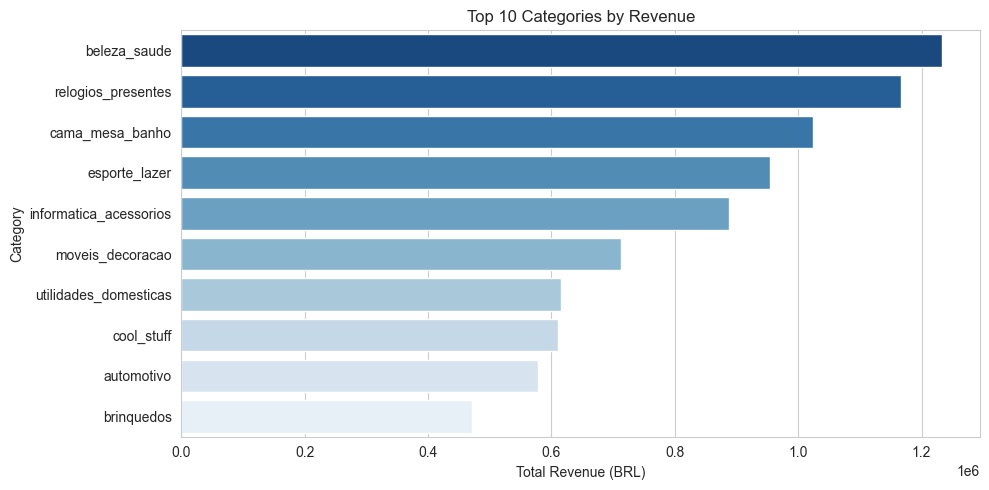

In [9]:
category_revenue = (
    df.groupby("category")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=category_revenue, x="price", y="category", palette="Blues_r")
plt.title("Top 10 Categories by Revenue")
plt.xlabel("Total Revenue (BRL)")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("chart1_category_revenue.png", dpi=150)
plt.show()

Question 2 — Monthly sales trend

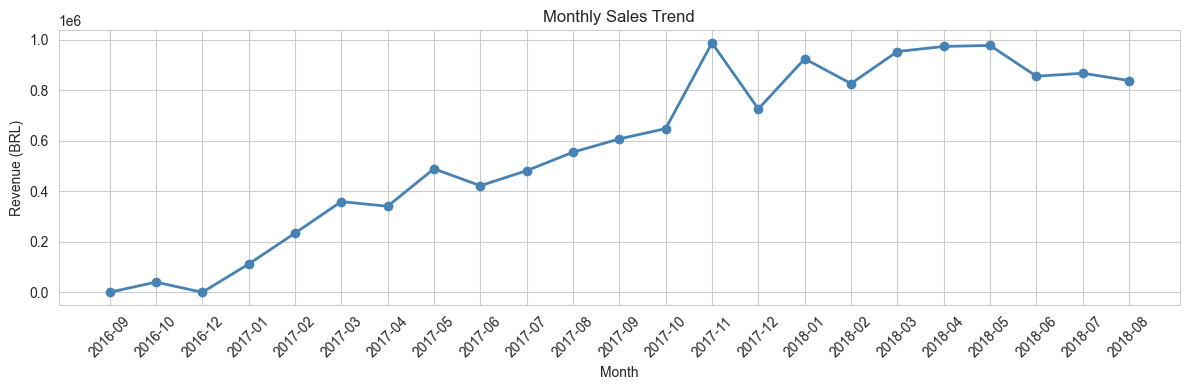

In [10]:
monthly_sales = (
    df.groupby("order_month")["price"]
    .sum()
    .reset_index()
)
monthly_sales["order_month"] = monthly_sales["order_month"].astype(str)

plt.figure(figsize=(12, 4))
plt.plot(monthly_sales["order_month"], monthly_sales["price"], 
         marker="o", color="steelblue", linewidth=2)
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (BRL)")
plt.tight_layout()
plt.savefig("chart2_monthly_trend.png", dpi=150)
plt.show()

Question 3 — Delivery delay distribution

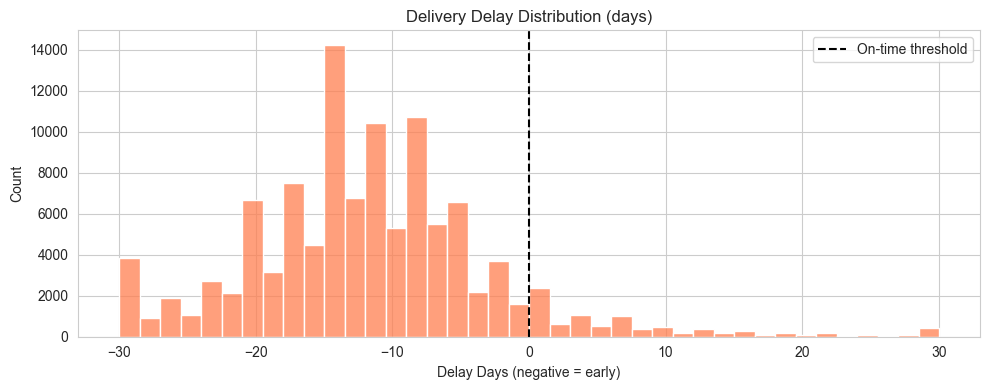

Late delivery rate: 6.6%


In [11]:
plt.figure(figsize=(10, 4))
sns.histplot(df["delivery_delay_days"].clip(-30, 30), bins=40, color="coral")
plt.axvline(0, color="black", linestyle="--", label="On-time threshold")
plt.title("Delivery Delay Distribution (days)")
plt.xlabel("Delay Days (negative = early)")
plt.legend()
plt.tight_layout()
plt.savefig("chart3_delivery_delay.png", dpi=150)
plt.show()

# % of late deliveries
late_pct = (df["delivery_delay_days"] > 0).mean() * 100
print(f"Late delivery rate: {late_pct:.1f}%")

Question 4 — Review score vs delivery delay

C:\Users\yadua\AppData\Local\Temp\ipykernel_23560\3771248464.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_delay_by_score, x="review_score",


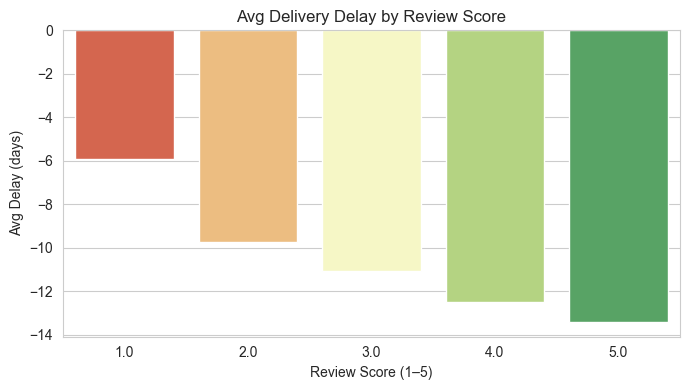

In [12]:
avg_delay_by_score = (
    df.groupby("review_score")["delivery_delay_days"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 4))
sns.barplot(data=avg_delay_by_score, x="review_score", 
            y="delivery_delay_days", palette="RdYlGn")
plt.title("Avg Delivery Delay by Review Score")
plt.xlabel("Review Score (1–5)")
plt.ylabel("Avg Delay (days)")
plt.tight_layout()
plt.savefig("chart4_review_vs_delay.png", dpi=150)
plt.show()

Question 5 — Key summary stats (for Power BI KPI cards)

In [13]:
print("=== PROJECT KPIs ===")
print(f"Total Orders: {df['order_id'].nunique():,}")
print(f"Total Revenue: R$ {df['price'].sum():,.0f}")
print(f"Avg Order Value: R$ {df.groupby('order_id')['price'].sum().mean():,.2f}")
print(f"Avg Review Score: {df['review_score'].mean():.2f}")
print(f"Late Delivery Rate: {(df['delivery_delay_days'] > 0).mean()*100:.1f}%")

=== PROJECT KPIs ===
Total Orders: 96,470
Total Revenue: R$ 13,220,249
Avg Order Value: R$ 137.04
Avg Review Score: 4.08
Late Delivery Rate: 6.6%
